# 9. Порівняльний аналіз алгоритмів кластеризації

Порівнюємо 5 алгоритмів на **4 парах атрибутів** (визначених за lift з Apriori):
1. **k-Means** — мінімізує суму квадратів відстаней
2. **k-Medians** — стійкий до викидів, L1 відстань
3. **Hierarchical** — агломеративний (Ward)
4. **KNN-clustering** — на основі графу найближчих сусідів
5. **DBSCAN** — на основі щільності

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

files = ['results_kmeans.csv', 'results_kmedians.csv', 'results_hierarchical.csv',
         'results_knn.csv', 'results_dbscan.csv']
results = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

with open('top4_pairs.json') as f:
    pairs = json.load(f)
pair_names = [f'{p[0]} + {p[1]}' for p in pairs]

print(f"Записів: {len(results)}, Пар: {len(pair_names)}, Алгоритмів: {results['algorithm'].nunique()}")
results
N = len(pairs)

Записів: 15, Пар: 3, Алгоритмів: 5


## 9.1 Silhouette Score по парах

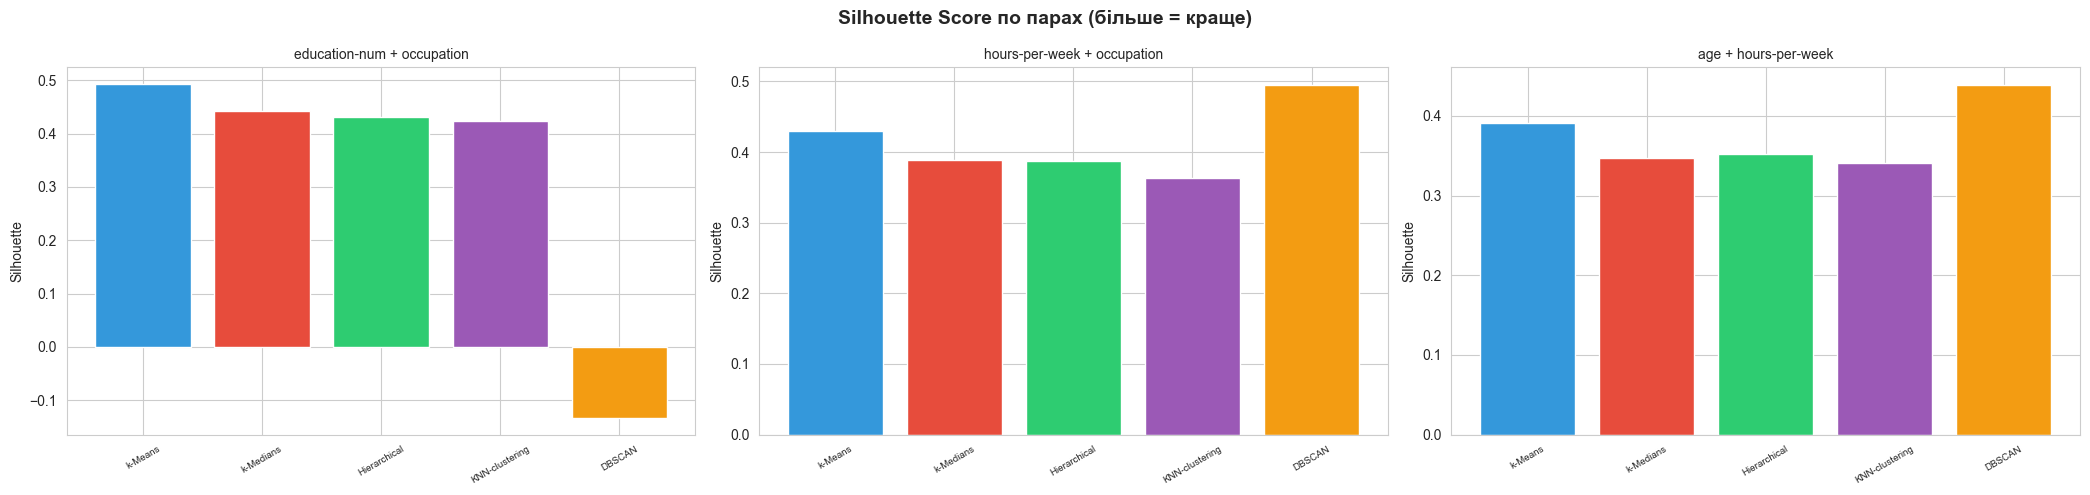

In [2]:
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']
algorithms = results['algorithm'].unique()

fig, axes = plt.subplots(1, N, figsize=(7*N, 5))
for j, pname in enumerate(pair_names):
    pdata = results[results['pair'] == pname]
    axes[j].bar(pdata['algorithm'], pdata['silhouette'], color=colors[:len(pdata)])
    axes[j].set_title(pname, fontsize=10)
    axes[j].set_ylabel('Silhouette')
    axes[j].tick_params(axis='x', rotation=30, labelsize=7)

plt.suptitle('Silhouette Score по парах (більше = краще)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9.2 Davies-Bouldin по парах

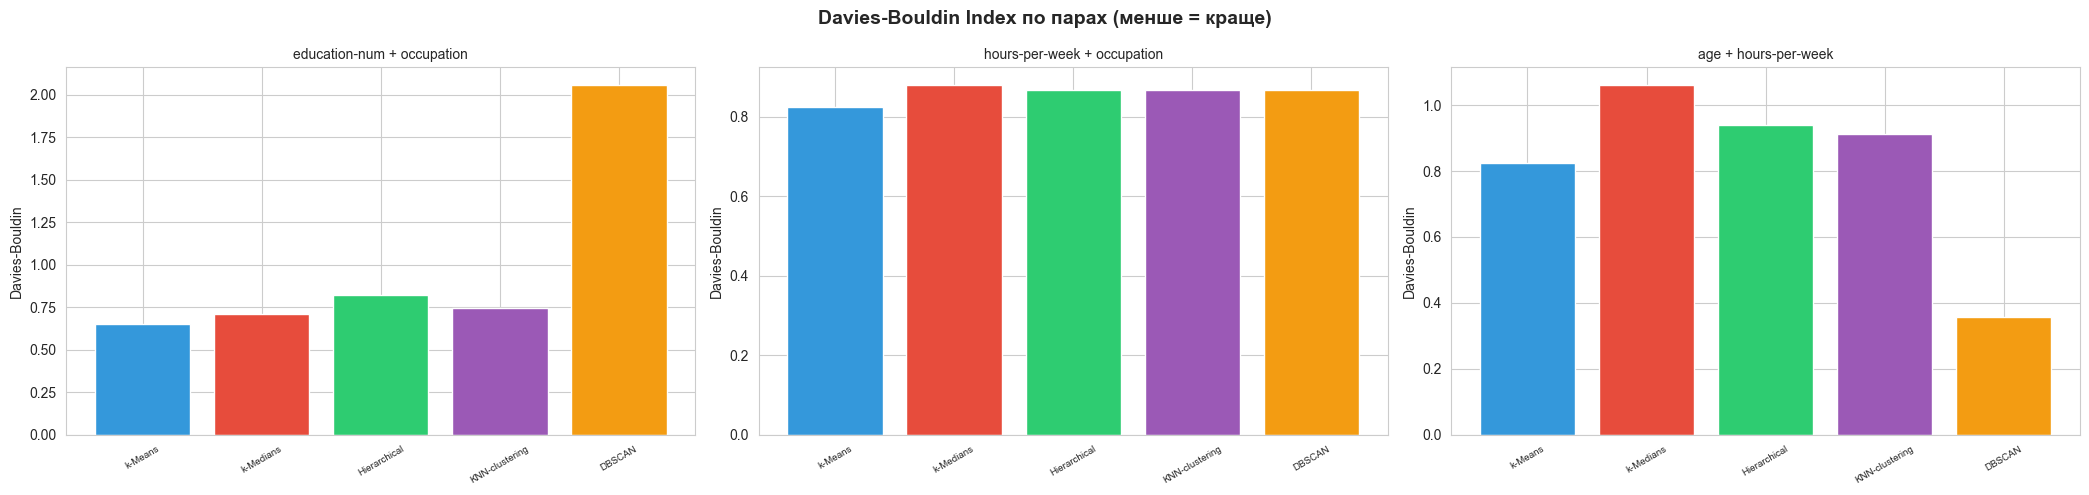

In [3]:
fig, axes = plt.subplots(1, N, figsize=(7*N, 5))
for j, pname in enumerate(pair_names):
    pdata = results[results['pair'] == pname]
    axes[j].bar(pdata['algorithm'], pdata['davies_bouldin'], color=colors[:len(pdata)])
    axes[j].set_title(pname, fontsize=10)
    axes[j].set_ylabel('Davies-Bouldin')
    axes[j].tick_params(axis='x', rotation=30, labelsize=7)

plt.suptitle('Davies-Bouldin Index по парах (менше = краще)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9.3 Heatmap: Silhouette (алгоритм x пара)

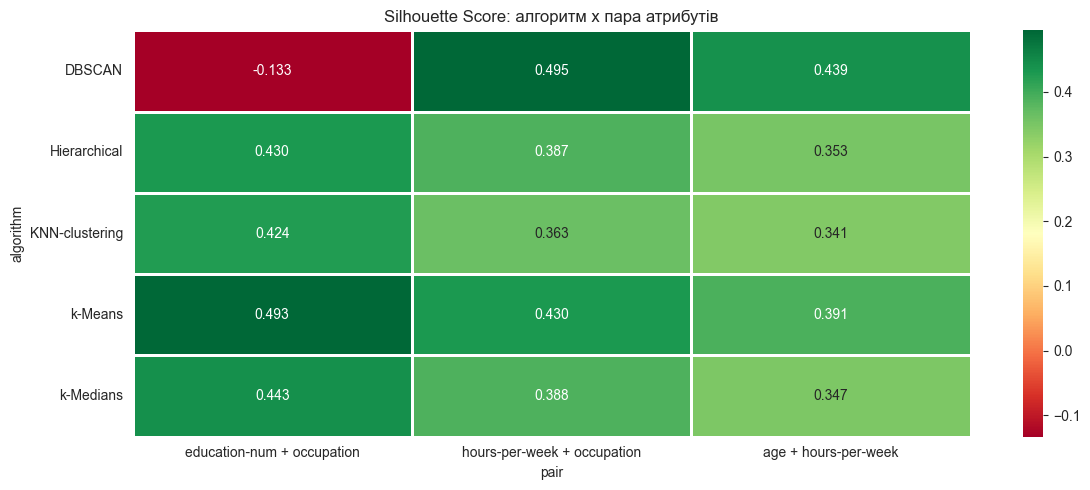

In [4]:
pivot = results.pivot_table(index='algorithm', columns='pair', values='silhouette')
pivot = pivot[pair_names]  # правильний порядок

plt.figure(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', linewidths=1)
plt.title('Silhouette Score: алгоритм x пара атрибутів')
plt.tight_layout()
plt.show()

## 9.4 Зведені таблиці

In [5]:
for pname in pair_names:
    pdata = results[results['pair'] == pname]
    print(f"\n{'='*85}")
    print(f"  {pname}")
    print(f"{'='*85}")
    print(f"{'Алгоритм':<18} {'k':>3} {'Silhouette':>12} {'Davies-Bouldin':>15} {'Calinski-H':>12} {'Час':>8}")
    print(f"{'-'*85}")
    for _, r in pdata.iterrows():
        print(f"{r['algorithm']:<18} {int(r['k']):>3} {r['silhouette']:>12.4f} {r['davies_bouldin']:>15.4f} {r['calinski_harabasz']:>12.1f} {r['time']:>8.3f}")
    best_sil = pdata.loc[pdata['silhouette'].idxmax(), 'algorithm']
    print(f"  >> Найкращий (Silhouette): {best_sil}")


  education-num + occupation
Алгоритм             k   Silhouette  Davies-Bouldin   Calinski-H      Час
-------------------------------------------------------------------------------------
k-Means              7       0.4929          0.6505      29591.9    0.098
k-Medians            7       0.4429          0.7101       6737.4    0.116
Hierarchical         8       0.4304          0.8232       4674.9    0.215
KNN-clustering       4       0.4244          0.7472       4050.6    5.145
DBSCAN              29      -0.1331          2.0594        385.6    0.066
  >> Найкращий (Silhouette): k-Means

  hours-per-week + occupation
Алгоритм             k   Silhouette  Davies-Bouldin   Calinski-H      Час
-------------------------------------------------------------------------------------
k-Means              4       0.4302          0.8250      18857.3    0.070
k-Medians            5       0.3883          0.8808       5103.2    0.125
Hierarchical         9       0.3874          0.8688       3467.1

## 9.5 Якість залежно від k

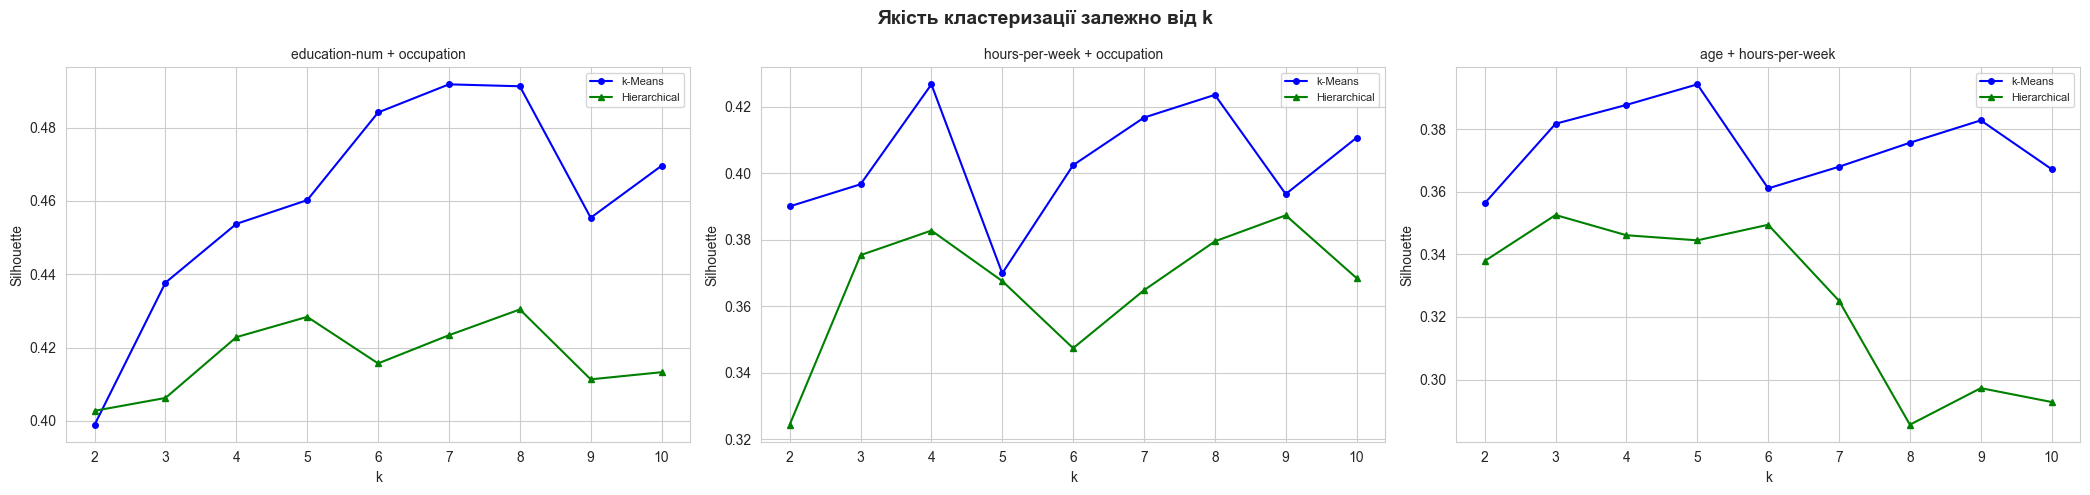

In [6]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

df_full = pd.read_csv('data_processed.csv')
np.random.seed(42)
idx = np.random.choice(len(df_full), 5000, replace=False)
df_comp = df_full.iloc[idx]

K_range = range(2, 11)
fig, axes = plt.subplots(1, N, figsize=(7*N, 5))

for j, pair in enumerate(pairs):
    X = StandardScaler().fit_transform(df_comp[pair].values)
    sil_km = [silhouette_score(X, KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)) for k in K_range]
    sil_h = [silhouette_score(X, AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X)) for k in K_range]
    
    axes[j].plot(list(K_range), sil_km, 'bo-', label='k-Means', markersize=4)
    axes[j].plot(list(K_range), sil_h, 'g^-', label='Hierarchical', markersize=4)
    axes[j].set_title(f'{pair[0]} + {pair[1]}', fontsize=10)
    axes[j].set_xlabel('k'); axes[j].set_ylabel('Silhouette')
    axes[j].legend(fontsize=8)

plt.suptitle('Якість кластеризації залежно від k', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Загальні висновки

### Асоціативні правила
- **education-num + occupation** — найсильніша асоціація (lift ~4.3): висока освіта → професійні спеціальності
- **age + marital-status** — молоді переважно неодружені (lift ~2.2)
- **hours-per-week + occupation** — часткова зайнятість у сервісних професіях (lift ~1.8)
- **age + hours-per-week** — молоді працюють менше годин (lift ~1.4)

### Порівняння алгоритмів
- **k-Means** — найшвидший, стабільні результати, добре працює на сферичних кластерах
- **k-Medians** — схожі результати, але стійкіший до викидів у age та hours-per-week
- **Hierarchical** — дендрограма дає візуальне розуміння структури; результати близькі до k-Means
- **KNN-clustering** — враховує локальну щільність, може знаходити кластери складної форми
- **DBSCAN** — не потребує k, але чутливий до eps; визначає шумові точки

### Якість залежно від k
- Для більшості пар оптимальне k=2-4
- Пари з категоріальними атрибутами (occupation, marital-status) мають природне розділення на кластери
- education-num + occupation дає найкращу якість кластеризації завдяки чіткому зв'язку між освітою та професією